# Item Effectiveness in Deadlock

The game Deadlock is a characters based 6v6 game where the objective is to defeat opponents and destroy their base. Each player accrues resources through these objectives and uses that income to purchase items. Deadlock's item system is very robust and intentionally provides items that counter specific traits that are common among characters. Characters that are mainly use abilities can be silenced, characters that mainly use their weapon can be disabled and so on. 

This project aims to investigate 5 specific characters and community perceived counter items. We'll look at the following:

| Archetype | Character | Item |
|----------|----------|----------|
| High Mobility | Mina | Slowing Hex | 
| Debuff / Damage over time | Infernus | Dispel Magic | 
| Channeled ability | Dynamo | Knockdown |
| Weapon | Vyper | Metal Skin | 
| Weapon | Haze | Disarming Hex |

Two chi squares are dedicated to weapon as I walso want to investigate the difference between offensive counter items (Disarming Hex) and reactive counter items (Metal Skin).

Dataset consists of 200k matches from the past 6 months with around 15k matches deemed high rank, sampled randomly over the course of said time. We will use a concentrated dataset of high rank players only for this portion, as counter items inherently have a more pronounced effect at lower ranks, where misplays are less punished. 

If time allows, an investigation of all items against all characters will calculated and composed into a volcano graph to see if there are items that have a distinct negative impact on a player's interaction with a character as an opponent. 


Polars to be used for 

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

hero_item_map = {
    "Mina":     np.uint32(1813726886),
    "Infernus": np.uint32(3731635960),
    "Vyper":    np.uint32(1378931225),
    "Dynamo":   np.uint32(1254091416),
    "Haze":     np.uint32(2061878743)
}

SKILL_CUTS     = {'low': (0, 99), 'high': (100, 9999)}
OTHER_TEAM     = {'Team0': 'Team1', 'Team1': 'Team0'}
DATA_FILES      = ['data/collected_matches.jsonl']


HIGH_RANK_BADGE = 100
FIGURES_DIR = 'figures'  # change to e.g. 'figures/recent_high' when using recent data


In [16]:
items_lookup = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

hero_id_map = {}

for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

upgrade_item_ids = set(items_lookup[items_lookup['type'] == 'upgrade']['id'])
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()

for hero in hero_item_map.keys():
    hero_id_map[hero] = heroes_lookup[heroes_lookup['name'] == hero]['id'].iloc[0]

In [17]:
import os


item_upgrades = {
    np.uint32(1813726886): np.uint32(1152158042),  # Slowing Hex → Vortex Web
}

player_rows = []
item_rows   = []

for path in DATA_FILES:
    if not os.path.exists(path):
        print(f" {path} not found")
        continue
    with open(path) as f:
        for line in f:
            try:
                match = json.loads(line)
            except json.JSONDecodeError:
                continue
            if match['average_badge_team0'] < HIGH_RANK_BADGE or match['average_badge_team1'] < HIGH_RANK_BADGE:
                continue
            mid = match['match_id']
            won = match['winning_team']
            for player in match['players']:
                team = player['team']
                player_rows.append({'match_id': mid, 'team': team, 'hero_id': player['hero_id'], 'won': int(team == won)})
                player_item_ids = {np.uint32(it['item_id']) for it in player['items']}
                for item in player['items']:
                    iid = np.uint32(item['item_id'])
                    if iid not in upgrade_item_ids:
                        continue
                    upgrade_id = item_upgrades.get(iid)
                    upgraded   = upgrade_id is not None and upgrade_id in player_item_ids
                    item_rows.append({'match_id': mid, 'team': team, 'hero_id': player['hero_id'],
                                      'won': int(team == won), 'item_id': iid,
                                      'held':     item['sold_time_s'] == 0 or upgraded,
                                      'was_sold': item['sold_time_s'] >  0 and not upgraded})

players_df = pd.DataFrame(player_rows)
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)

items_df = pd.DataFrame(item_rows)
items_df['item_name'] = items_df['item_id'].map(item_id_to_name)

## 1. Hold Rate and Win Rate

For each item/hero combination, how effective is the item actually? 

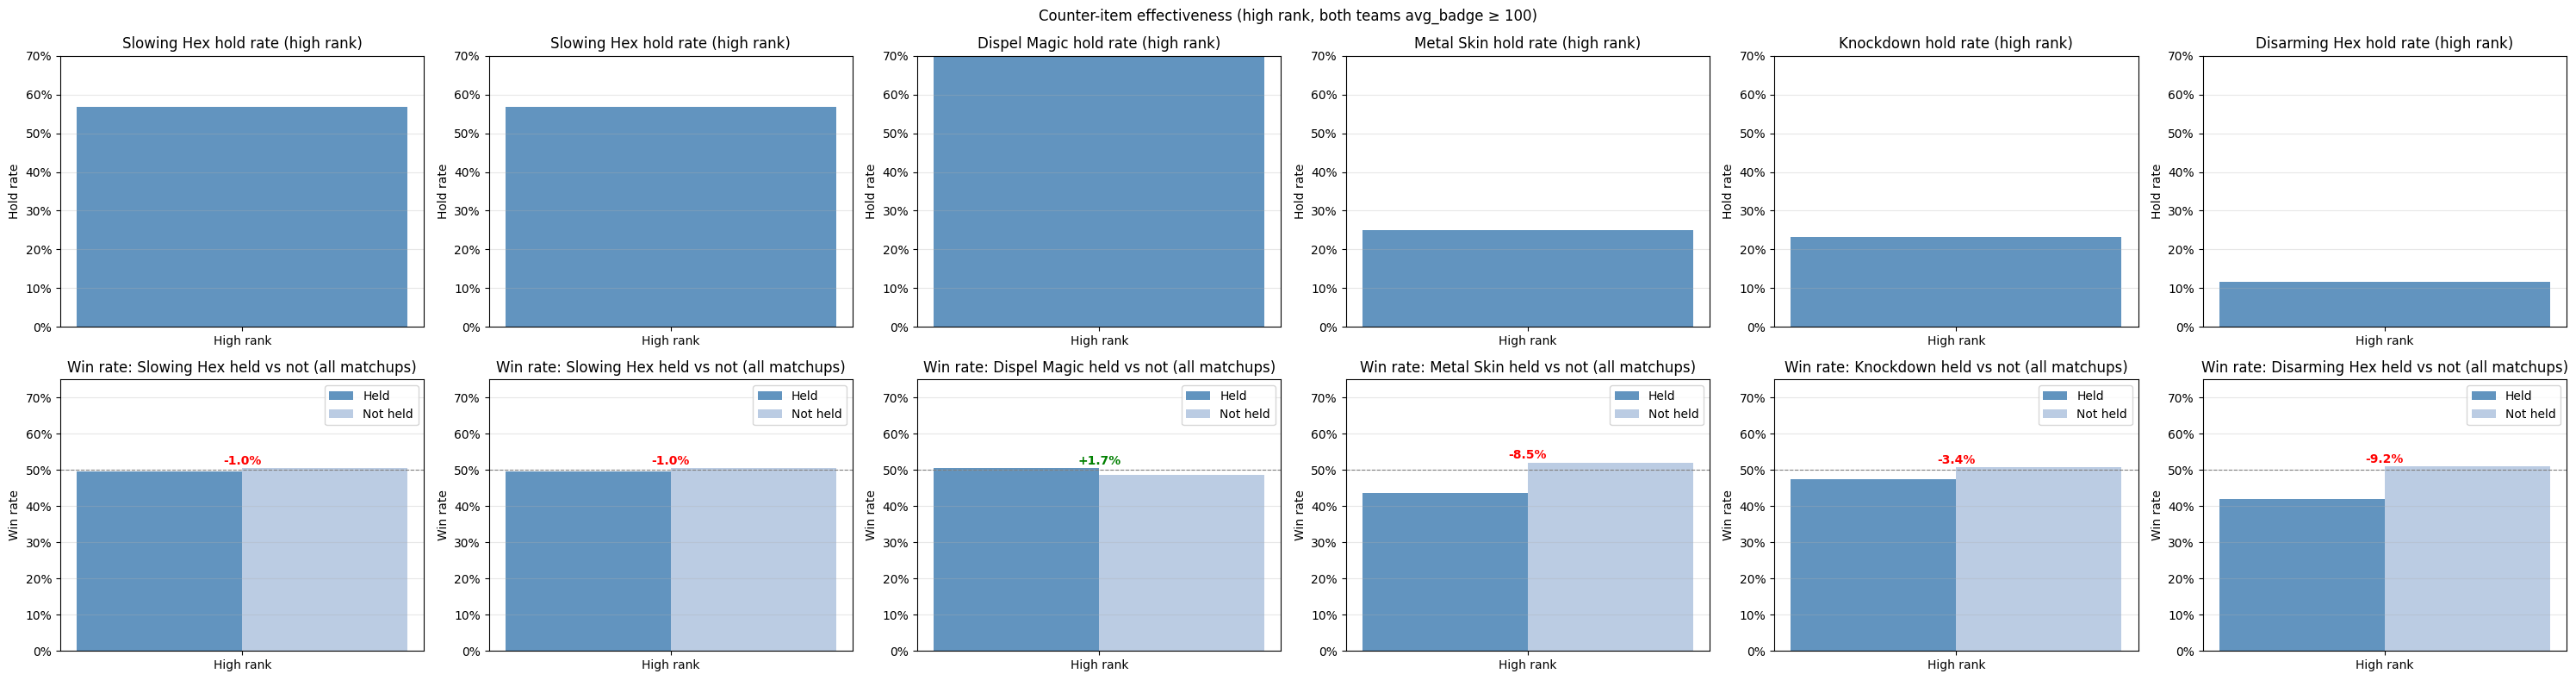

In [18]:
outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

fig, axes = plt.subplots(2, len(hero_item_map), figsize=(5 * len(hero_item_map), 8))

for i, (hero, item_id) in enumerate(hero_item_map.items()):
    item_held = (
        items_df[(items_df['item_id'] == item_id) & items_df['held']]
        [['match_id', 'team']]
        .drop_duplicates()
        .assign(held_item=1)
    )

    team_df = outcomes.merge(item_held, on=['match_id', 'team'], how='left')
    team_df['held_item'] = team_df['held_item'].fillna(0).astype(int)

    held      = team_df[team_df['held_item'] == 1]['won']
    not_held  = team_df[team_df['held_item'] == 0]['won']
    hold_rate = team_df['held_item'].mean()
    delta     = held.mean() - not_held.mean()
    item_name = item_id_to_name[item_id]

    ax0, ax1 = axes[0, i], axes[1, i]

    ax0.bar(['High rank'], [hold_rate], color='steelblue', alpha=0.85)
    ax0.set_ylabel('Hold rate')
    ax0.set_title(f'{item_name} hold rate (high rank)')
    ax0.yaxis.set_major_formatter('{x:.0%}')
    ax0.set_ylim(0, 0.7)
    ax0.grid(axis='y', alpha=0.3)

    w, x = 0.35, np.array([0])
    ax1.bar(x - w/2, [held.mean()],     w, label='Held',     color='steelblue',      alpha=0.85)
    ax1.bar(x + w/2, [not_held.mean()], w, label='Not held', color='lightsteelblue', alpha=0.85)
    ax1.annotate(f'{delta:+.1%}',
                 xy=(0, max(held.mean(), not_held.mean()) + 0.01),
                 ha='center', fontsize=10, color='green' if delta > 0 else 'red', fontweight='bold')
    ax1.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
    ax1.set_xticks(x); ax1.set_xticklabels(['High rank'])
    ax1.set_ylim(0, 0.75); ax1.set_ylabel('Win rate')
    ax1.set_title(f'Win rate: {item_name} held vs not (all matchups)')
    ax1.yaxis.set_major_formatter('{x:.0%}')
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)

plt.suptitle('Counter-item effectiveness (high rank, both teams avg_badge ≥ 100)', fontsize=12)
plt.tight_layout()
import os
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(f'{FIGURES_DIR}/01_hold_rate_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Characters With High Purchase Rates Regardless of Matchup

Are there characters who buy items often labelled as counter items because they synergize with their abilities? Let's identify them for our specific item cases.  

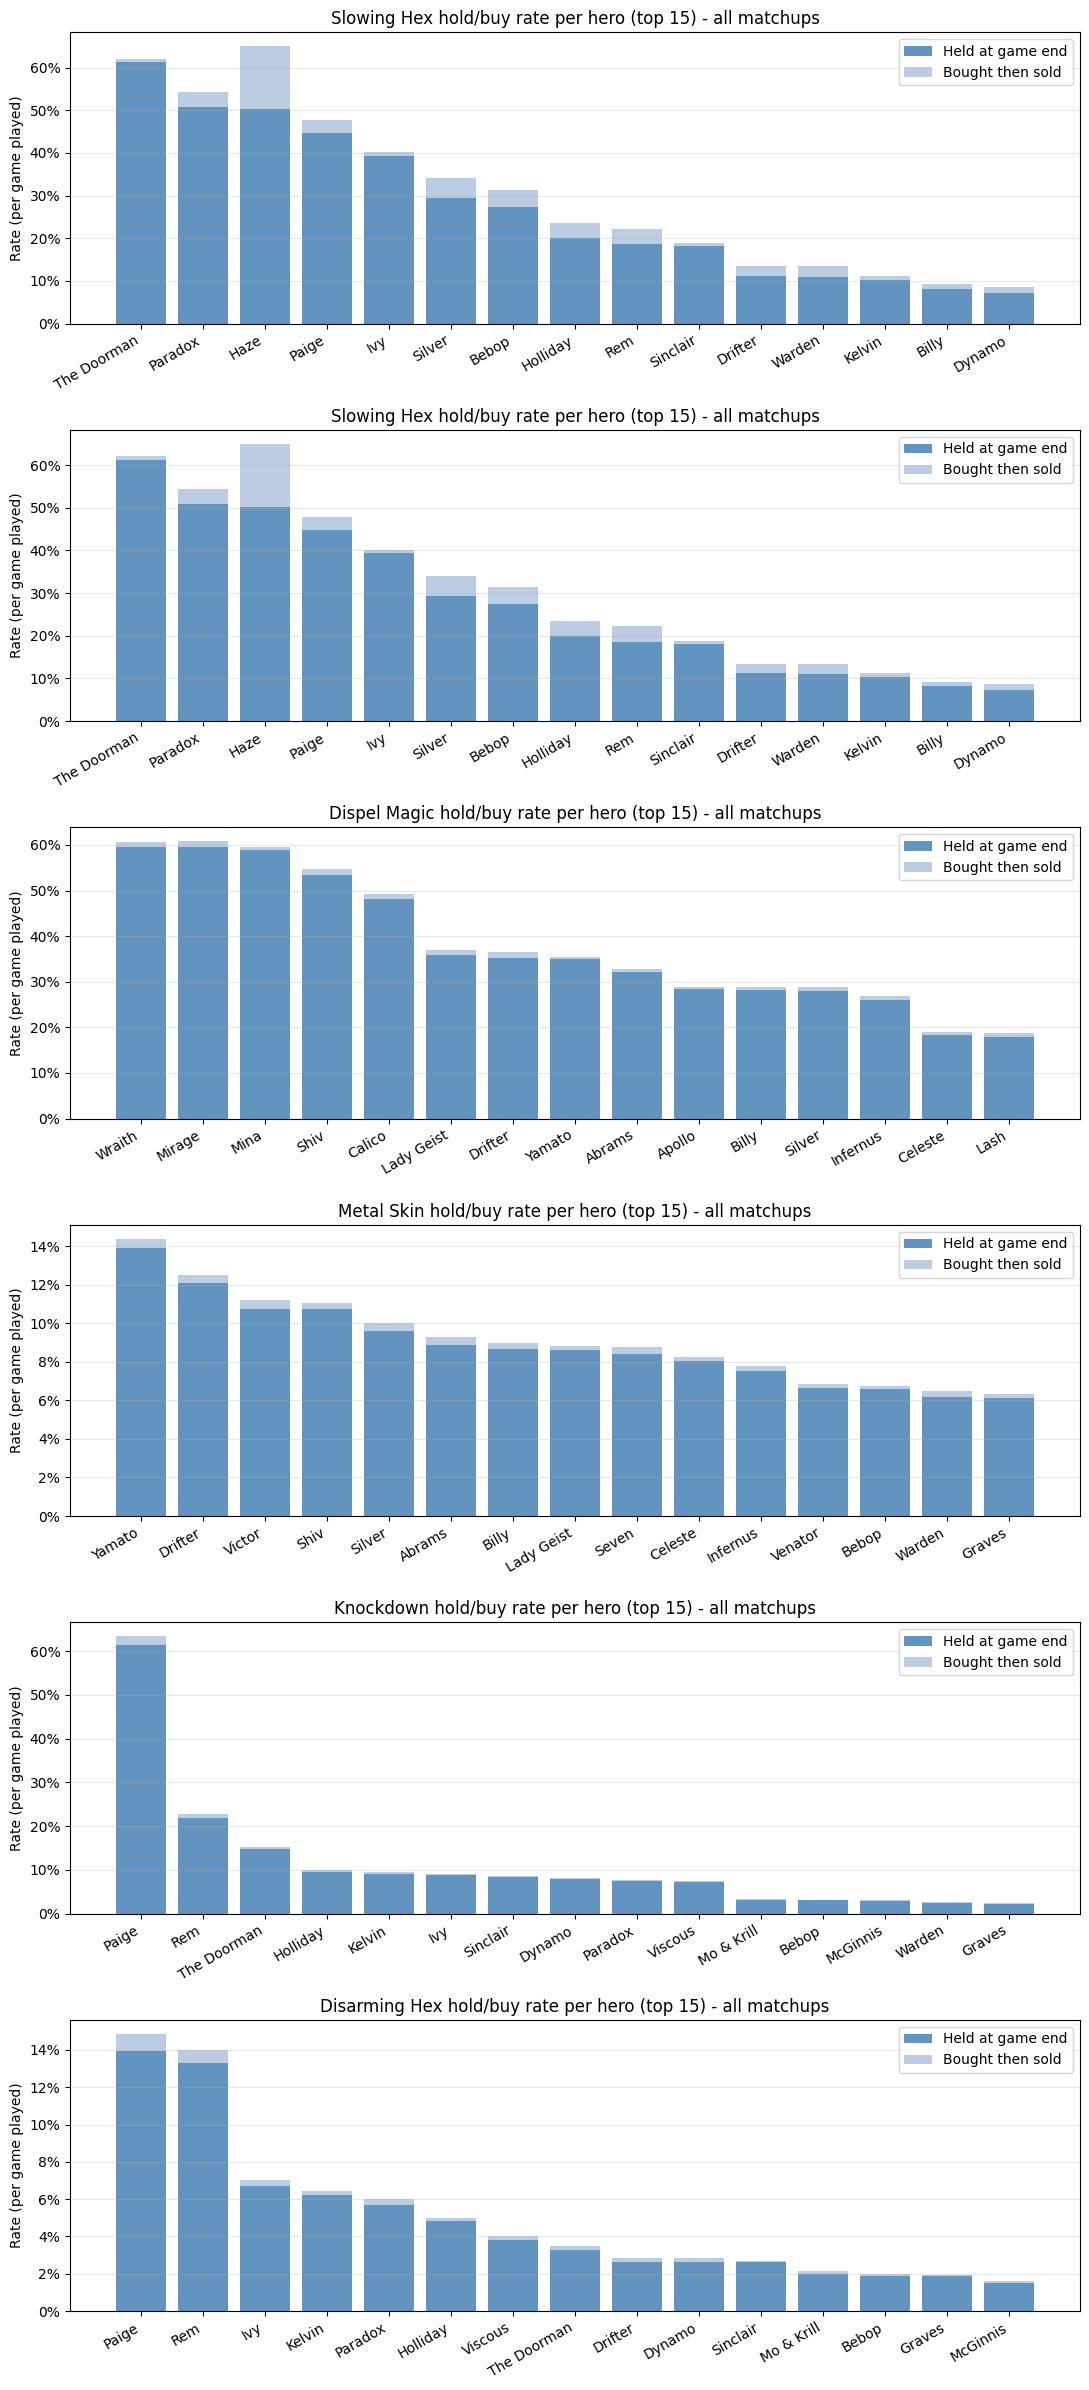

In [19]:
hero_games = players_df.groupby('hero_id').size().rename('games')

fig, axes = plt.subplots(len(hero_item_map), 1, figsize=(11, 4 * len(hero_item_map)))

for i, (hero, item_id) in enumerate(hero_item_map.items()):
    item_name = item_id_to_name[item_id]
    by_hero = (
        items_df[items_df['item_id'] == item_id]
        .groupby('hero_id')
        .agg(times_bought=('held', 'count'), times_held=('held', 'sum'))
        .reset_index()
        .merge(hero_games, on='hero_id')
        .assign(
            hero_name=lambda d: d['hero_id'].map(hero_id_to_name),
            hold_rate=lambda d: d['times_held']  / d['games'],
            buy_rate= lambda d: d['times_bought'] / d['games'],
        )
        .sort_values('hold_rate', ascending=False)
    )

    top = by_hero.head(15)
    ax = axes[i]
    x = np.arange(len(top))
    ax.bar(x, top['hold_rate'], color='steelblue', alpha=0.85, label='Held at game end')
    ax.bar(x, top['buy_rate'] - top['hold_rate'], bottom=top['hold_rate'],
           color='lightsteelblue', alpha=0.85, label='Bought then sold')
    ax.set_xticks(x); ax.set_xticklabels(top['hero_name'], rotation=30, ha='right')
    ax.set_ylabel('Rate (per game played)')
    ax.yaxis.set_major_formatter('{x:.0%}')
    ax.set_title(f'{item_name} hold/buy rate per hero (top 15) - all matchups')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_item_buy_rate_per_hero.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Core Builders vs Situational Buyers × Enemy Hero

Does the win rate lift hold for situational buyers (who bought specifically to counter) vs core builders (who buy it regardless)?

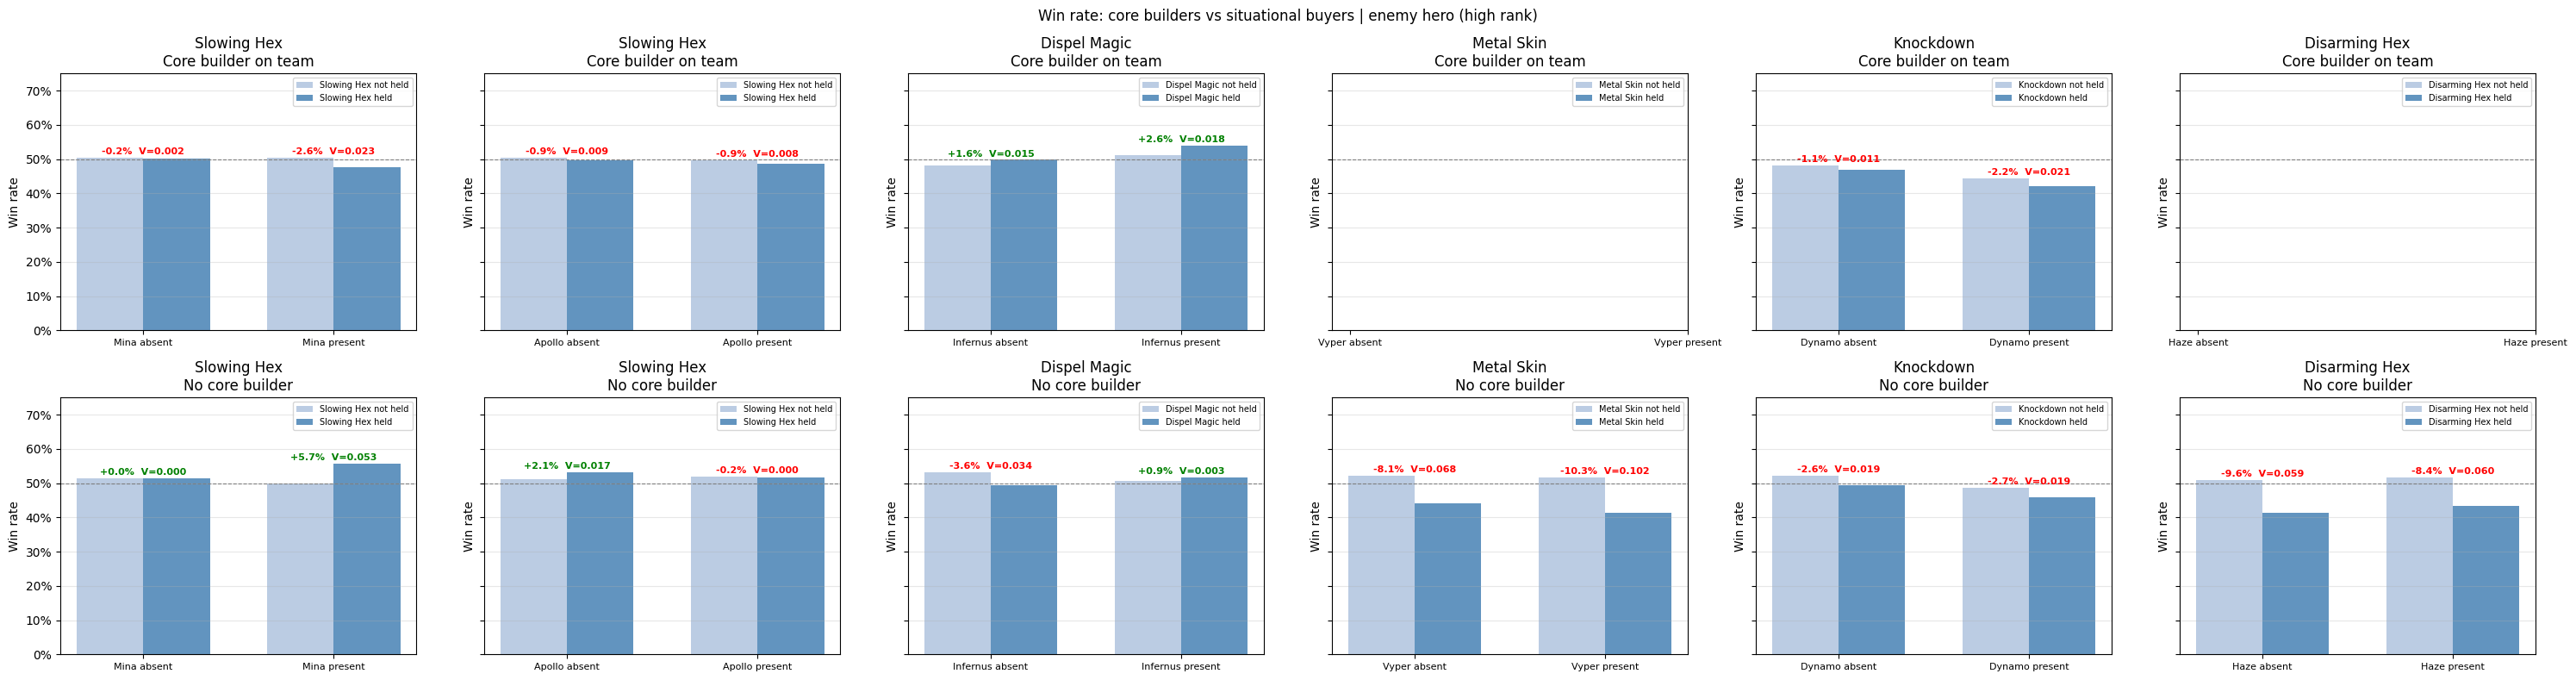

In [20]:
CORE_THRESHOLD = 0.20

def cramers_v(chi2, n):
    return np.sqrt(chi2 / n)

group_labels = ['Core builder on team', 'No core builder']
fig, axes = plt.subplots(2, len(hero_item_map), figsize=(5 * len(hero_item_map), 8), sharey=True)

for i, (hero, item_id) in enumerate(hero_item_map.items()):
    item_name  = item_id_to_name[item_id]
    target_hid = hero_id_map[hero]

    item_held = (
        items_df[(items_df['item_id'] == item_id) & items_df['held']]
        [['match_id', 'team']]
        .drop_duplicates()
        .assign(held_item=1)
    )

    enemy_present = (
        players_df[players_df['hero_id'] == target_hid][['match_id', 'team']]
        .assign(team=lambda d: d['team'].map(OTHER_TEAM), enemy_present=1)
    )

    core_heroes = set(
        items_df[items_df['item_id'] == item_id]
        .groupby('hero_id')
        .agg(times_held=('held', 'sum'))
        .reset_index()
        .merge(hero_games, on='hero_id')
        .assign(hold_rate=lambda d: d['times_held'] / d['games'])
        .pipe(lambda d: d[d['hold_rate'] >= CORE_THRESHOLD]['hero_id'])
    )

    has_core_builder = (
        players_df[players_df['hero_id'].isin(core_heroes)]
        [['match_id', 'team']]
        .drop_duplicates()
        .assign(has_core_builder=1)
    )

    team_df = (
        outcomes
        .merge(item_held,        on=['match_id', 'team'], how='left')
        .merge(enemy_present,    on=['match_id', 'team'], how='left')
        .merge(has_core_builder, on=['match_id', 'team'], how='left')
        .fillna(0)
    )
    for col in ['held_item', 'enemy_present', 'has_core_builder']:
        team_df[col] = team_df[col].astype(int)

    enemy_labels = [f'{hero} absent', f'{hero} present']

    for j, builder_mask in enumerate([1, 0]):
        rows = []
        for enemy_mask in [0, 1]:
            grp      = team_df[(team_df['has_core_builder'] == builder_mask) & (team_df['enemy_present'] == enemy_mask)]
            held     = grp[grp['held_item'] == 1]['won']
            not_held = grp[grp['held_item'] == 0]['won']

            p, v = np.nan, np.nan
            if len(held) >= 5 and len(not_held) >= 5:
                ct = np.array([[int(held.sum()), len(held) - int(held.sum())],
                               [int(not_held.sum()), len(not_held) - int(not_held.sum())]])
                chi2, p, _, _ = chi2_contingency(ct, correction=True)
                v = cramers_v(chi2, ct.sum())

            rows.append({
                'matchup':     enemy_labels[enemy_mask],
                'wr_held':     held.mean()     if len(held)     > 0 else np.nan,
                'wr_not_held': not_held.mean() if len(not_held) > 0 else np.nan,
                'wr_delta':    held.mean() - not_held.mean() if len(held) > 0 and len(not_held) > 0 else np.nan,
                'p_value':     round(p, 4) if not np.isnan(p) else np.nan,
                'cramers_v':   round(v, 4) if not np.isnan(v) else np.nan,
            })

        sub = pd.DataFrame(rows).set_index('matchup')
        ax  = axes[j, i]
        x, w = np.arange(len(enemy_labels)), 0.35
        ax.bar(x - w/2, sub['wr_not_held'], w, label=f'{item_name} not held', color='lightsteelblue', alpha=0.85)
        ax.bar(x + w/2, sub['wr_held'],     w, label=f'{item_name} held',     color='steelblue',      alpha=0.85)
        for k, row in enumerate(sub.itertuples()):
            if pd.isna(row.wr_delta): continue
            v_str = f'  V={row.cramers_v:.3f}' if not pd.isna(row.cramers_v) else ''
            ax.annotate(f'{row.wr_delta:+.1%}{v_str}',
                        xy=(k, max(row.wr_held or 0, row.wr_not_held or 0) + 0.01),
                        ha='center', fontsize=8, color='green' if row.wr_delta > 0 else 'red', fontweight='bold')
        ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
        ax.set_xticks(x); ax.set_xticklabels(enemy_labels, fontsize=8)
        ax.set_ylim(0, 0.75)
        ax.set_ylabel('Win rate')
        ax.set_title(f'{item_name}\n{group_labels[j]}')
        ax.yaxis.set_major_formatter('{x:.0%}')
        ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

fig.suptitle('Win rate: core builders vs situational buyers | enemy hero (high rank)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_core_vs_situational.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
summary_rows = []

for hero, item_id in hero_item_map.items():
    item_name  = item_id_to_name[item_id]
    target_hid = hero_id_map[hero]

    item_held = (
        items_df[(items_df['item_id'] == item_id) & items_df['held']]
        [['match_id', 'team']].drop_duplicates().assign(held_item=1)
    )
    enemy_present = (
        players_df[players_df['hero_id'] == target_hid][['match_id', 'team']]
        .assign(team=lambda d: d['team'].map(OTHER_TEAM), enemy_present=1)
    )
    core_heroes = set(
        items_df[items_df['item_id'] == item_id]
        .groupby('hero_id').agg(times_held=('held', 'sum')).reset_index()
        .merge(hero_games, on='hero_id')
        .assign(hold_rate=lambda d: d['times_held'] / d['games'])
        .pipe(lambda d: d[d['hold_rate'] >= CORE_THRESHOLD]['hero_id'])
    )
    has_core_builder = (
        players_df[players_df['hero_id'].isin(core_heroes)]
        [['match_id', 'team']].drop_duplicates().assign(has_core_builder=1)
    )
    team_df = (
        outcomes
        .merge(item_held,        on=['match_id', 'team'], how='left')
        .merge(enemy_present,    on=['match_id', 'team'], how='left')
        .merge(has_core_builder, on=['match_id', 'team'], how='left')
        .fillna(0)
    )
    for col in ['held_item', 'enemy_present', 'has_core_builder']:
        team_df[col] = team_df[col].astype(int)

    sit = team_df[team_df['has_core_builder'] == 0]
    row = {'Hero': hero, 'Item': item_name}

    for ep, label in [(0, 'absent'), (1, 'present')]:
        grp      = sit[sit['enemy_present'] == ep]
        held     = grp[grp['held_item'] == 1]['won']
        not_held = grp[grp['held_item'] == 0]['won']
        delta    = float(held.mean() - not_held.mean()) if len(held) > 0 and len(not_held) > 0 else np.nan
        row[f'delta_{label}'] = round(delta, 4)
        if ep == 1 and len(held) >= 5 and len(not_held) >= 5:
            ct = np.array([[int(held.sum()), len(held) - int(held.sum())],
                           [int(not_held.sum()), len(not_held) - int(not_held.sum())]])
            chi2_val, p, _, _ = chi2_contingency(ct, correction=True)
            row["Cramér's V"] = round(cramers_v(chi2_val, ct.sum()), 3)
            row['p-value']    = round(p, 4)

    row['Relative lift'] = round(row['delta_present'] - row['delta_absent'], 4)
    summary_rows.append(row)

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values('Relative lift', ascending=False)
    .rename(columns={'delta_absent': 'ΔWR (absent)', 'delta_present': 'ΔWR (present)'})
    .reset_index(drop=True)
)

display(summary_df[['Hero', 'Item', 'ΔWR (absent)', 'ΔWR (present)', 'Relative lift', "Cramér's V", 'p-value']])

summary_df.to_csv(f'{FIGURES_DIR}/counter_item_summary.csv', index=False)
print(f'Saved → {FIGURES_DIR}/counter_item_summary.csv')

## 4. All-Hero Item Effectiveness — Volcano Plot (high rank)

For every (upgrade item × opponent hero) pair in the already-loaded high-rank dataset, tests whether holding the item is associated with a higher win rate when facing that hero. BH correction applied globally across all pairs.

In [ ]:
from statsmodels.stats.multitest import multipletests

VOLCANO_MIN_N_WITH    = 20
VOLCANO_MIN_N_WITHOUT = 5
VOLCANO_THRESH_P      = 0.05
VOLCANO_THRESH_OR     = 1.2

held_wide = (
    items_df[items_df['held']]
    .groupby(['match_id', 'team', 'item_name'])
    .size().gt(0).astype(int)
    .rename('held')
    .reset_index()
    .pivot_table(index=['match_id', 'team'], columns='item_name',
                 values='held', aggfunc='max', fill_value=0)
    .reset_index()
)
held_wide.columns.name = None
item_cols = [c for c in held_wide.columns if c not in ('match_id', 'team')]

item_slot = items_lookup[items_lookup['type'] == 'upgrade'].set_index('name')['slot_type'].to_dict()

base_df = outcomes.merge(held_wide, on=['match_id', 'team'], how='left')
base_df[item_cols] = base_df[item_cols].fillna(0).astype(int)

volcano_rows = []
for hero_id in players_df['hero_id'].unique():
    hero_name = hero_id_to_name.get(int(hero_id), str(hero_id))
    enemy_flag = (
        players_df[players_df['hero_id'] == hero_id][['match_id', 'team']]
        .assign(enemy=1)
        .assign(team=lambda d: d['team'].map(OTHER_TEAM))
    )
    team_df = base_df.merge(enemy_flag, on=['match_id', 'team'], how='left')
    team_df['enemy'] = team_df['enemy'].fillna(0).astype(int)
    facing = team_df[team_df['enemy'] == 1]

    for item in item_cols:
        with_item    = facing[facing[item] == 1]['won']
        without_item = facing[facing[item] == 0]['won']
        n1, n0 = len(with_item), len(without_item)
        if n1 < VOLCANO_MIN_N_WITH or n0 < VOLCANO_MIN_N_WITHOUT:
            continue
        a, b = int(with_item.sum()), n1 - int(with_item.sum())
        c, d = int(without_item.sum()), n0 - int(without_item.sum())
        if b == 0 or c == 0:
            continue
        chi2_val, p, _, _ = chi2_contingency(np.array([[a, b], [c, d]]), correction=False)
        or_val = (a * d) / (b * c)
        volcano_rows.append({
            'hero': hero_name, 'item': item,
            'slot_type': item_slot.get(item, 'unknown'),
            'n_with': n1, 'wr_with': round(float(with_item.mean()), 3),
            'wr_without': round(float(without_item.mean()), 3),
            'wr_delta': round(float(with_item.mean() - without_item.mean()), 3),
            'or': or_val, 'log2_or': np.log2(or_val), 'p_raw': p,
        })

vdf = pd.DataFrame(volcano_rows)
_, vdf['p_bh'], _, _ = multipletests(vdf['p_raw'], method='fdr_bh')
vdf['neg_log10_bh'] = -np.log10(vdf['p_bh'].clip(lower=1e-300))

log2_thresh = np.log2(VOLCANO_THRESH_OR)
def categorise_v(row):
    if row['p_bh'] >= VOLCANO_THRESH_P:   return 'non-significant'
    if row['log2_or'] >  log2_thresh:     return 'beneficial'
    if row['log2_or'] < -log2_thresh:     return 'detrimental'
    return 'significant-small-effect'
vdf['category'] = vdf.apply(categorise_v, axis=1)

print(f'Total (hero × item) pairs tested: {len(vdf):,}')
print(vdf['category'].value_counts().to_string())

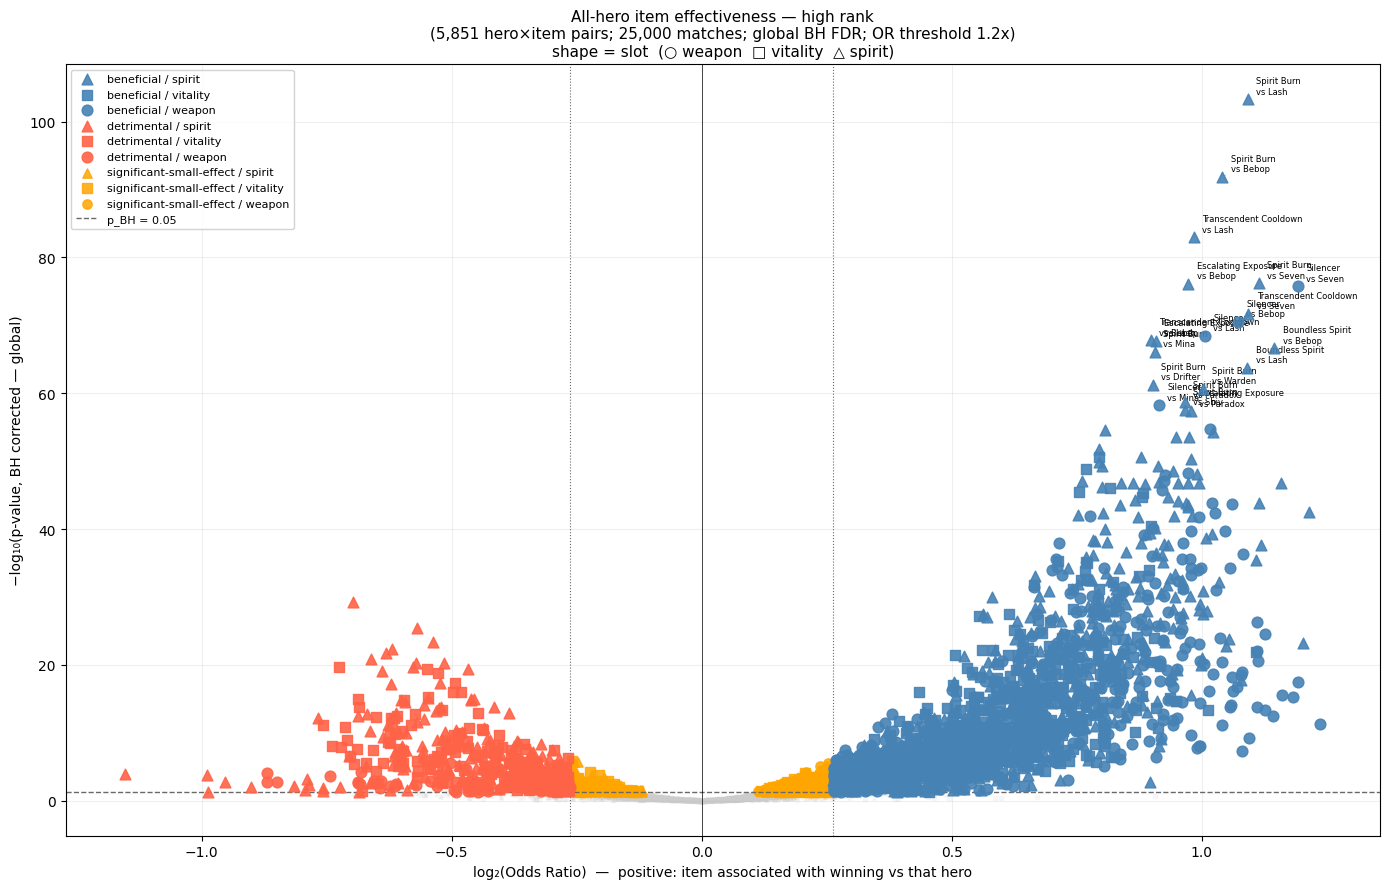

In [ ]:
palette      = {'beneficial': 'steelblue', 'detrimental': 'tomato',
                'significant-small-effect': 'orange', 'non-significant': '#cccccc'}
z_order      = {'non-significant': 1, 'significant-small-effect': 2, 'detrimental': 3, 'beneficial': 4}
sizes  = {'beneficial': 60, 'detrimental': 60, 'significant-small-effect': 45, 'non-significant': 7}
alphas = {'beneficial': 0.9, 'detrimental': 0.9, 'significant-small-effect': 0.85, 'non-significant': 0.12}
slot_markers = {'weapon': 'o', 'vitality': 's', 'spirit': '^', 'unknown': 'D'}

fig, ax = plt.subplots(figsize=(14, 9))

for cat, grp in vdf.groupby('category'):
    for slot, sgrp in grp.groupby('slot_type'):
        ax.scatter(sgrp['log2_or'], sgrp['neg_log10_bh'],
                   c=palette[cat], marker=slot_markers.get(slot, 'o'),
                   alpha=alphas[cat], s=sizes[cat], zorder=z_order.get(cat, 2),
                   label=f'{cat} / {slot}' if cat != 'non-significant' else None)

ax.axhline(-np.log10(VOLCANO_THRESH_P), color='dimgrey', linestyle='--', linewidth=1,
           label=f'p_BH = {VOLCANO_THRESH_P}')
ax.axvline( log2_thresh, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(-log2_thresh, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(0,            color='black',   linewidth=0.5)

sig_top = vdf[vdf['category'].isin(['beneficial', 'detrimental'])].nlargest(20, 'neg_log10_bh')
for _, row in sig_top.iterrows():
    ax.annotate(f"{row['item']}\nvs {row['hero']}",
                xy=(row['log2_or'], row['neg_log10_bh']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=6, color='black',
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.4))

n_matches = players_df['match_id'].nunique()
ax.set_xlabel('log₂(Odds Ratio)  —  positive: item associated with winning vs that hero', fontsize=10)
ax.set_ylabel('−log₁₀(p-value, BH corrected — global)', fontsize=10)
ax.set_title(
    f'All-hero item effectiveness — high rank\n'
    f'({len(vdf):,} hero×item pairs; {n_matches:,} matches; global BH FDR; OR threshold {VOLCANO_THRESH_OR}x)\n'
    f'shape = slot  (○ weapon  □ vitality  △ spirit)',
    fontsize=11,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
          loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_volcano_high_rank.png', dpi=150, bbox_inches='tight')
plt.show()